In [1]:
!pip install mediapipe tflite_support

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.3/390.3 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached pybind11-3.0.2-py3-none-any.whl.metadata (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.3 MB/s eta 0:00:00
Using cached pybind11-3.0.2-py3-none-any.whl (310 kB)
  Created wheel for tflite_support: filename=tflite_support-0.1.0a1-cp312-cp312-linux_x86_64.whl size=6335008 sha256=5e48ae6ea545be0f3b312e266754c941d0824c78f15dd05d3d7e41b0bf20badf
  Stored in directory: /root/.cache/pip/wheels/5d/6f/bc/8b85ad0e51d3c8f82c590b321f2c5b35c41fbe84ad93271397
Successfully built tflite_support
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [2]:
import cv2
import numpy as np
import mediapipe as mp
from matplotlib import pyplot as plt

def visualize(image, detection_result) -> np.ndarray:
    """Draws bounding boxes on the input image and return it."""

    # Convert the image to a numpy array (for OpenCV)
    annotated_image = image.numpy_view().copy()

    # Loop through every object detected
    for detection in detection_result.detections:

        # 1. Get the Bounding Box
        bbox = detection.bounding_box
        start_point = (bbox.origin_x, bbox.origin_y)
        end_point = (bbox.origin_x + bbox.width, bbox.origin_y + bbox.height)

        # 2. Draw the rectangle (Color: Red, Thickness: 3)
        cv2.rectangle(annotated_image, start_point, end_point, (255, 0, 0), 3)

        # 3. Get the Label and Score
        category = detection.categories[0]
        category_name = category.category_name
        probability = round(category.score, 2)

        # 4. Draw the Text
        result_text = f"{category_name} ({probability})"
        text_location = (bbox.origin_x, bbox.origin_y - 10)
        cv2.putText(annotated_image, result_text, text_location, cv2.FONT_HERSHEY_PLAIN,
                    2, (255, 0, 0), 2)

    return annotated_image

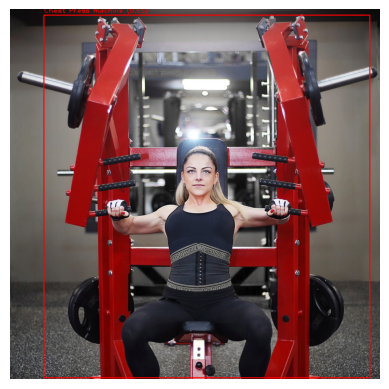

Found 1 objects:
- Chest Press machine (0.65)


In [4]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request

# 1. Configuration
base_options = python.BaseOptions(model_asset_path='gym_equipment_model.tflite')
options = vision.ObjectDetectorOptions(base_options=base_options,
                                       score_threshold=0.5)
detector = vision.ObjectDetector.create_from_options(options)

# 2. Load the Image from URL
image_url = 'https://cdn.webshopapp.com/shops/112842/files/308873981/1652x1652x1/chest-press-machine-while-sitting-6axx2-dual-with.jpg'
test_image_path = 'test_image.jpg'
urllib.request.urlretrieve(image_url, test_image_path)

image = mp.Image.create_from_file(test_image_path)

# 3. Detect
detection_result = detector.detect(image)

# 4. Display Results
image_copy = visualize(image, detection_result)
plt.imshow(image_copy)
plt.axis('off')
plt.show()

# Optional: Print text results
print(f"Found {len(detection_result.detections)} objects:")
for detection in detection_result.detections:
    print(f"- {detection.categories[0].category_name} ({detection.categories[0].score:.2f})")

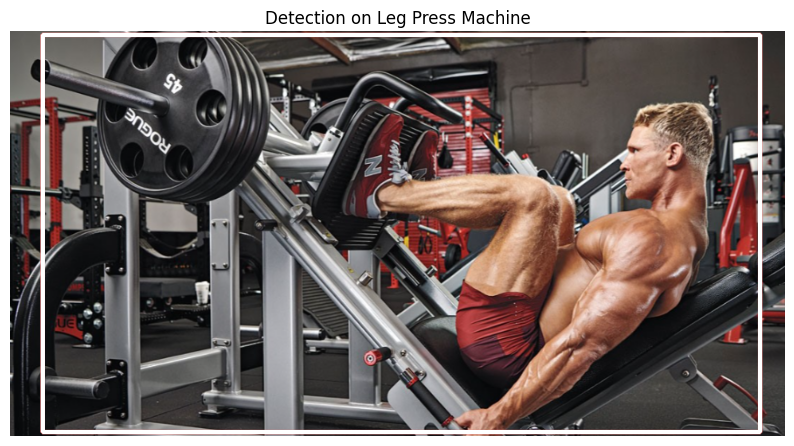

Found 1 objects:
- Chest Press machine (0.82)


In [8]:
# 1. Load the new Image from URL
new_image_url = 'https://www.untappedsupplement.com/cdn/shop/articles/leg_press_cover.png?v=1695189587'
new_test_image_path = 'leg_press.jpg'
urllib.request.urlretrieve(new_image_url, new_test_image_path)

new_image = mp.Image.create_from_file(new_test_image_path)

# 2. Detect
new_detection_result = detector.detect(new_image)

# 3. Display Results
new_image_copy = visualize(new_image, new_detection_result)
plt.figure(figsize=(10,10))
plt.imshow(new_image_copy)
plt.axis('off')
plt.title('Detection on Leg Press Machine')
plt.show()

# 4. Print results
print(f"Found {len(new_detection_result.detections)} objects:")
for detection in new_detection_result.detections:
    category = detection.categories[0]
    print(f"- {category.category_name} ({category.score:.2f})")

In [ ]:
import tensorflow as tf

interpreter = tf.lite.Interpreter(model_path="gym_equipment_model.tflite")
interpreter.allocate_tensors()

print("INPUTS:")
for d in interpreter.get_input_details():
    print(d["name"], d["shape"], d["dtype"])

print("\nOUTPUTS:")
for d in interpreter.get_output_details():
    print(d["name"], d["shape"], d["dtype"])


In [ ]:
from tflite_support.metadata import MetadataDisplayer

d = MetadataDisplayer.with_model_file("gym_equipment_model.tflite")
print(d.get_metadata_json())

print("\nAssociated files:")
print(d.get_packed_associated_file_list())


In [ ]:
import tensorflow as tf

saved_model_dir = "/content"

converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
converter.allow_custom_ops = True
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
tflite_model = converter.convert()

open("detect_with_postprocess.tflite", "wb").write(tflite_model)
